In [1]:
import sys
sys.path.append('../datasets')
sys.path.append('../algorithms')
sys.path.append('../test')


import torch

import matplotlib.pyplot as plt
from pansharpening_static import PANHandler
from load_pavia import load_pavia
from alg2 import PANTVCB
from torchvision import transforms
from math import sqrt
from PIL import Image , ImageFont,ImageDraw

/home/ndiayem/Documents/spectral-spatial/env/lib/python3.11/site-packages/kornia/feature/lightglue.py:44: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @torch.cuda.amp.custom_fwd(cast_inputs=torch.float32)


In [2]:
# Define device (default is "cpu")
device = "cpu" 

    # Define dtype
dtype = torch.float64
crop_size = 256
    # Define random seed
seed = 42
torch.manual_seed(seed)

    # Define data path
data_path = '/home/ndiayem/Documents/spectral-spatial/data/Pavia.mat'

rgb = [29,19,9]

In [63]:
hsi_data = load_pavia(data_path)
_, b, h,w = hsi_data.shape

c = 32
idx = [[h//2 - c, h//2 + c], [w//2-c, w//2 + c]]
X = hsi_data[:,rgb, idx[0][0]:idx[0][1], idx[1][0]:idx[1][1]]
	
_, b, h,w = X.shape
PAN = PANHandler(nband=b, 
                 size=(h,w),
                 scale=4,
                 sigma=1,
                 noise_level=1,
                 seed=42 
                 )

Loaded HSI data with shape: torch.Size([1, 102, 1096, 715])
Number of spectral bands: 102


In [64]:
# Matrice de transformation

Y_H = PAN.simulate_low_res_hsi(X)  
Y_M = PAN.get_panchromatic(X)

In [65]:
A,A_adj, R, R_adj = PAN.get_operators()

#gain = 1.0
#lmbda = 1e10
#step_size = 1e-6
#lmbda_m = 1000
#tol = 1e-7
#max_iter = 1000
#max_iter_cp = 10

#params = {
#    'max_iter': max_iter_cp,         # niters → max_iter (nom attendu par TVPrior)         
#   'lmbda' : lmbda * step_size,  # paramètre supplémentaire
#   'theta': 1 ,            # paramètre de régularisation
#    'sigma': gain,                  # sigma = gain (gain=2)   
#   'tau': 0.99/gain             # tau = 0.99 / gain (calculé)     
#}


params = {
    'max_iter': 10,         # niters → max_iter (nom attendu par TVPrior)         
    'lmbda' : 0.01,  # paramètre supplémentaire
    'theta': 1 ,            # paramètre de régularisation
    'sigma': 2,                  # sigma = gain (gain=2)   
    'tau': 0.99/2             # tau = 0.99 / gain (calculé)     
}

p,q,r = 2, 2, 1

solver = PANTVCB(
    A=A,
    Aadj=A_adj,
    spectral_op = R,
    spectral_op_t = R_adj,
    max_iter=2000,
    lmbda=0.01,
    lmbda_m=0.5,
    tol=1e-7,
    scale=PAN.scale,
    p = p,
    q = q,
    r = r,
    verbose=True,
    params = params
)

In [66]:
U, costs = solver(Y_H, Y_M)

2025-07-21 16:29:06,649 - INFO - 
Début de l'optimisation:
2025-07-21 16:29:06,649 - INFO - 
Début de l'optimisation:
2025-07-21 16:29:06,649 - INFO - 
Début de l'optimisation:
2025-07-21 16:29:06,649 - INFO - 
Début de l'optimisation:
2025-07-21 16:29:06,649 - INFO - 
Début de l'optimisation:
2025-07-21 16:29:06,649 - INFO - 
Début de l'optimisation:
2025-07-21 16:29:06,649 - INFO - 
Début de l'optimisation:
2025-07-21 16:29:06,657 - INFO - It    | Coût total   | Data H       | Data M       | TV           | ΔU          
2025-07-21 16:29:06,657 - INFO - It    | Coût total   | Data H       | Data M       | TV           | ΔU          
2025-07-21 16:29:06,657 - INFO - It    | Coût total   | Data H       | Data M       | TV           | ΔU          
2025-07-21 16:29:06,657 - INFO - It    | Coût total   | Data H       | Data M       | TV           | ΔU          
2025-07-21 16:29:06,657 - INFO - It    | Coût total   | Data H       | Data M       | TV           | ΔU          
2025-07-21 16:29:

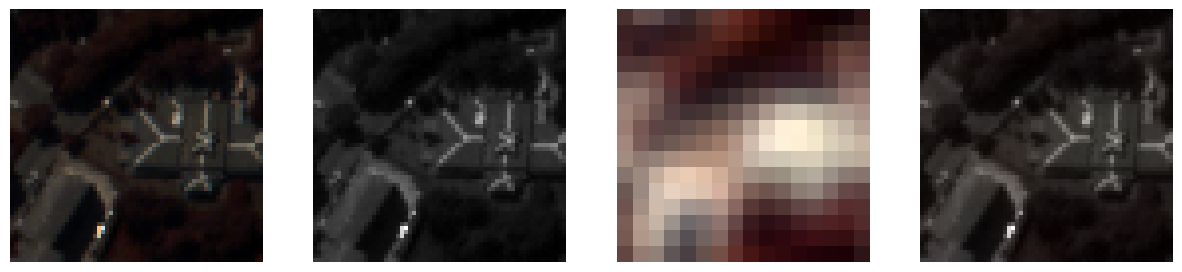

In [68]:

x_rgb = X[0, ...].cpu().numpy().transpose(1, 2, 0)
x_rgb = (x_rgb - x_rgb.min())/(x_rgb.max() - x_rgb.min())

y_rgb = Y_H[0, ...].cpu().numpy().transpose(1, 2, 0)
y_rgb = (y_rgb - y_rgb.min())/(y_rgb.max() - y_rgb.min())

z_rgb = U[0, ...].cpu().numpy().transpose(1, 2, 0)
z_rgb = (z_rgb - z_rgb.min())/(z_rgb.max() - z_rgb.min())

plt.figure(figsize=(15, 5))
plt.subplot(141)
plt.imshow(x_rgb)
# plt.title('RGB')
plt.axis('off')

plt.subplot(142)
plt.imshow(Y_M[0, 0, ...].cpu().numpy(), cmap='gray')
# plt.title('Panchromatic')
plt.axis('off')

plt.subplot(143)
plt.imshow(y_rgb)
# plt.title('Noisy RGB')
plt.axis('off')

plt.subplot(144)
plt.imshow(z_rgb)
# plt.title('Noisy RGB')=4
plt.axis('off')

plt.show()

Dimensions vérifiées: iterations (2000,), cout_total 2000


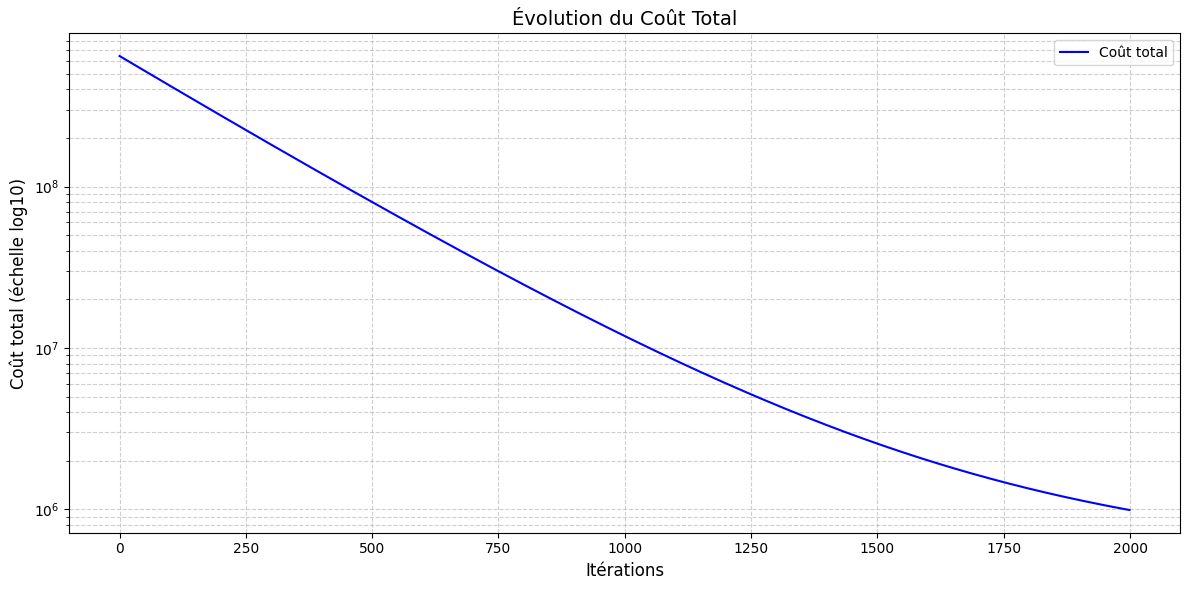

In [69]:
import matplotlib.pyplot as plt
import numpy as np

# Données d'exemple (à adapter avec vos données réelles)
cout_total = costs

# Création du vecteur d'itérations de même longueur que cout_total
iterations = np.arange(0, len(cout_total))  # Pas de 10 entre les mesures

# Vérification des dimensions
print(f"Dimensions vérifiées: iterations {iterations.shape}, cout_total {len(cout_total)}")

# Création du graphique
plt.figure(figsize=(12, 6))
plt.semilogy(iterations, cout_total, 'b-', linewidth=1.5, label='Coût total')

# Personnalisation
plt.xlabel('Itérations', fontsize=12)
plt.ylabel('Coût total (échelle log10)', fontsize=12)
plt.title('Évolution du Coût Total', fontsize=14)
plt.grid(True, which="both", linestyle='--', alpha=0.6)

# Affichage
plt.legend()
plt.tight_layout()
plt.show()

In [70]:
from deepinv.loss.metric import PSNR

m = PSNR()
P = m(U,X)
print(P)

tensor([-38.3900])


In [31]:
import torch
from torchvision import transforms
from PIL import Image
to_pil = transforms.ToPILImage()

In [32]:
image1 = to_pil(x_rgb)
image1.save('image1.png')

In [33]:
image2 = to_pil(Y_M[0, 0, ...])
image2.save('image2.png')

In [34]:
image3 = to_pil(y_rgb)
image3.save('image3.png')

In [35]:
image4 = to_pil(z_rgb)
image4.save('image4.png')